In [1]:
import pandas as pd 
import numpy as np 

import umap 

import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.preprocessing import Normalizer, StandardScaler
from sklearn.model_selection import train_test_split

import pickle as pk

/Users/sean/Documents/FrancoisLab/venv/lib/python3.9/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/sean/Documents/FrancoisLab/venv/lib/python3.9/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/sean/Documents/FrancoisLab/venv/lib/python3.9/site-packag

# Data loading and pre-processing. 

In [2]:
data = pd.read_hdf("../../TC_Antigen_encoding-main/initialSingleCellDf-channel-20220916-MW_018-001.h5", key="df")
MARKERS = data.columns
ANTIGENS = ['null', 'E1', 'G4', 'V4', 'T4', 'Q4', 'A2', 'N4']

In [3]:
# Filter the data to the strong antigens, first repliate, OT-1 cells, high concentration, and later. 
df = data.loc[(data.index.get_level_values('CellType') == 'OT-1') & 
                     #   (data.index.get_level_values('Concentration') == '1uM') & 
                       (data.index.get_level_values('Replicate') == '1') &
                       (data.index.get_level_values('Time') >= 0.0) & # [4.0, 12.0, 24.0, 30.0, 36.0, 48.0, 60.0, 72.0]
                       (data.index.get_level_values('Peptide').isin(ANTIGENS))
                    ]

Now, for the training purposes, we will average across identical conditions in groups of tento reduce the size of the training set and reduce overfitting. 

In [4]:
group_size = 20

def avg(group): 
    group['GroupNumber'] = np.array(range(len(group.index))) // group_size
    res = group.groupby('GroupNumber').mean()
    return res

averaged_df = df.groupby(['Peptide', 'Time', 'Concentration']).apply(avg)

In [5]:
antigen = list(averaged_df.index.get_level_values('Peptide'))
time = list(averaged_df.index.get_level_values('Time'))
concentrations = list(averaged_df.index.get_level_values('Concentration'))

In [6]:
X = np.array(averaged_df.values)
y = list(map(lambda x: ANTIGENS.index(x), antigen))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

In [7]:
X_train.shape

(76113, 26)

# Model loading. 
The data above was loaded in the same way as `high_quality_data.ipynb` and the model we will be loading is the same model that was trained in that notebook. 

In [8]:
with open("../high_quality_data/full_data_model.pk", 'rb') as f:
    # Load the pickled object
    model = pk.load(f)
model

UMAP(min_dist=0.4, n_neighbors=40, random_state=42, tqdm_kwds={'bar_format': '{desc}: {percentage:3.0f}%| {bar} {n_fmt}/{total_fmt} [{elapsed}]', 'desc': 'Epochs completed', 'disable': True})

In [9]:
train_embedding = model.transform( StandardScaler().fit_transform(X_train) )

In [10]:
test_embedding = model.transform( StandardScaler().fit_transform(X_test) )

/Users/sean/Documents/FrancoisLab/venv/lib/python3.9/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
OMP: Info #271: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Text(0.5, 1.0, 'UMAP over Averaged Data (Validation)')

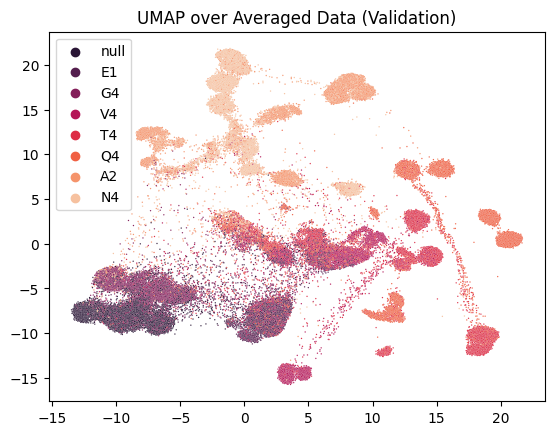

In [11]:
sns.scatterplot(
    x=test_embedding[:,0], 
    y=test_embedding[:,1], 
    hue=pd.Categorical(list(map(lambda x : ANTIGENS[x], y_test))), 
    palette="rocket", 
    hue_order=ANTIGENS,
    s=1
)
plt.title("UMAP over Averaged Data (Validation)")

# Predictive power. 
Now, we will make predictions on the VALIDATION DATA and create a confusion matrix to test how the UMAP performs. 

I will do this by doing K-means clustering on the embedding and then transforming and classifying based on the K-means in the latent space. 

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix

In [13]:
clustering = KMeans(n_clusters=len(ANTIGENS))
clustering.fit( train_embedding )

KMeans()

In [14]:
dists = clustering.transform( test_embedding )
dists

array([[ 2.7323446, 28.714603 , 18.231224 , ..., 13.840111 , 19.090973 ,
        30.78158  ],
       [10.799836 , 16.521711 ,  8.447271 , ...,  3.7596827, 17.729916 ,
        24.272757 ],
       [12.221822 , 13.952129 ,  3.436793 , ...,  9.654362 , 12.240773 ,
        18.609365 ],
       ...,
       [29.454027 ,  5.2897415, 15.246452 , ..., 20.811829 , 25.390469 ,
        20.65958  ],
       [17.723808 , 16.331522 ,  8.700871 , ..., 19.275097 ,  3.8516002,
        11.174339 ],
       [19.066595 , 12.447874 , 11.115965 , ...,  8.489533 , 22.992002 ,
        25.33455  ]], dtype=float32)

In [15]:
y_pred = np.argmin( dists, axis=1 )
y_true = y_test #np.argmax(y_test, axis=1) 

cm = confusion_matrix(y_true, y_pred)

cm

array([[8359,    0,  120,    0,    0,  388,   10,    0],
       [ 823,    0, 1308,    0,    0, 4074,    0,    0],
       [7796,    5,  264,    0,    0,  388,   51,    0],
       [ 366,  758, 4643,   15,    0, 3125,   44,    0],
       [ 284, 3816, 2725, 3704,    3,  532,   73,    1],
       [ 175, 6834, 1886, 2278,    9,  422,   33,   54],
       [ 349,   71, 1557,    6, 1270,    9, 2555, 3946],
       [ 258,   66, 1509,   20, 5304,   18, 3302,  507]])

In [16]:
# TODO 
# Reshuffle the columns of the confusion matrix to account for the fact that we dont know which cluster 
# corresponds to which category. We will assume that it gets it right most of the time to determine which column is which. 

N = cm.shape[0]

for i in range(N): 
    line = cm[i,i:]
    j = np.argmax(line)
    t = np.copy(cm[:,i])
    cm[:,i] = np.copy(cm[:,j+i])
    cm[:,j+i] = t

cm

array([[8359,  388,  120,    0,    0,    0,   10,    0],
       [ 823, 4074, 1308,    0,    0,    0,    0,    0],
       [7796,  388,  264,    5,    0,    0,   51,    0],
       [ 366, 3125, 4643,  758,   15,    0,   44,    0],
       [ 284,  532, 2725, 3816, 3704,    1,   73,    3],
       [ 175,  422, 1886, 6834, 2278,   54,   33,    9],
       [ 349,    9, 1557,   71,    6, 3946, 2555, 1270],
       [ 258,   18, 1509,   66,   20,  507, 3302, 5304]])

[Text(0, 0.5, 'null'),
 Text(0, 1.5, 'E1'),
 Text(0, 2.5, 'G4'),
 Text(0, 3.5, 'V4'),
 Text(0, 4.5, 'T4'),
 Text(0, 5.5, 'Q4'),
 Text(0, 6.5, 'A2'),
 Text(0, 7.5, 'N4')]

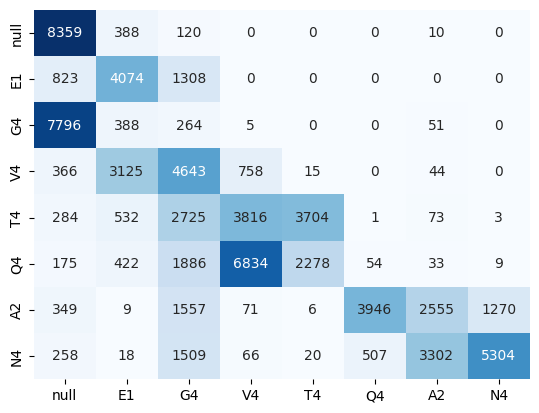

In [17]:
# Create a figure and axes
fig, ax = plt.subplots()

# Create the heatmap using seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)

# Set labels for the x and y axes
ax.set_xticklabels(ANTIGENS)
ax.set_yticklabels(ANTIGENS)

It looks like the the UMAP is able to quite easily predict what the antigen is. 